# Entrega 3 — Chunking de Manifestações Longas

**Ouvidoria Inteligente: triagem semântica de manifestações cidadãs**

Manifestações longas costumam relatar vários problemas no mesmo texto (alagamento **e** falta de ônibus, calor na sala **e** biblioteca fechada...). Quando um texto desses é indexado como um único bloco, o embedding vira uma "média" dos assuntos e perde contexto.

Neste notebook, as **5 manifestações mais longas** são divididas em chunks com o `RecursiveCharacterTextSplitter` do LangChain. Quatro configurações de `(chunk_size, chunk_overlap)` são comparadas para responder às perguntas do enunciado:

1. Como o overlap influencia a coesão semântica entre chunks consecutivos?
2. Qual configuração preserva melhor o sentido das denúncias?
3. No espaço 2D, os chunks de uma mesma manifestação ficam próximos?

In [9]:
# Bibliotecas (as variáveis de ambiente escondem barras de progresso e avisos do download dos modelos)
import json
import os

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 200)

## 1. As 5 manifestações mais longas

In [10]:
with open("manifestacoes.json", encoding="utf-8") as arquivo:
    manifestacoes = json.load(arquivo)

df = pd.DataFrame(manifestacoes)
df["tamanho"] = df["texto"].str.len()
longas = df.sort_values("tamanho", ascending=False).head(5).reset_index(drop=True)
longas[["id", "categoria_oficial", "tamanho", "texto"]]

,id,categoria_oficial,tamanho,texto
0,M025,saúde,646,"Quero relatar o que aconteceu com meu pai na UPA do bairro Oitizeiro. Ele chegou com dor no peito às oito da noite e só foi atendido depois da meia-noite, sentado numa cadeira de plástico no corre..."
1,M020,infraestrutura,626,"Venho, mais uma vez, registrar a situação da Rua Projetada 12, no bairro Gramame. Sempre que chove forte a rua inteira alaga, porque não existe drenagem e as bocas de lobo estão entupidas de lixo ..."
2,M036,educação,623,"Sou mãe de dois alunos da escola municipal do bairro Gramame e preciso relatar vários problemas. O transporte escolar atrasa quase todos os dias e, quando chove, simplesmente não passa, porque a e..."
3,M030,segurança,621,"Sou comerciante no centro da cidade e escrevo em nome de vários lojistas da Rua Duque de Caxias. Nos últimos dois meses, pelo menos seis lojas foram arrombadas durante a madrugada. A iluminação da..."
4,M040,meio ambiente,591,"Moro às margens do rio Jaguaribe e preciso denunciar a situação ambiental da região. Há canos despejando esgoto diretamente no rio, e a água, que antes era usada pelos pescadores, agora está escur..."


## 2. Configurações de chunking

Os textos têm entre 590 e 650 caracteres. As configurações foram escolhidas para isolar o efeito de cada parâmetro:

| Config. | chunk_size | chunk_overlap | O que testa |
|---|---|---|---|
| A | 200 | 0 | chunks pequenos, **sem** overlap |
| B | 200 | 50 | mesmo tamanho de A, com um overlap **pequeno** (25%) |
| C | 350 | 70 | chunks maiores, com overlap de 20% |
| D | 350 | 180 | chunks maiores, com um overlap **grande**, maior que uma frase típica |

**Detalhe importante do LangChain:** o overlap não é aplicado caractere a caractere. O splitter primeiro corta o texto nos separadores (aqui, em frases) e depois junta os pedaços até o `chunk_size`. O overlap só consegue repetir **pedaços inteiros** do chunk anterior que caibam dentro de `chunk_overlap`. Como as frases destes textos têm de 70 a 175 caracteres, um overlap de 50 ou 70 não comporta nenhuma frase inteira, e a configuração D foi incluída justamente para ter um overlap capaz de repetir frases.

Os separadores seguem a ordem de preferência do splitter recursivo: parágrafo, linha, fim de frase, vírgula, espaço. Com `keep_separator="end"`, o ponto final fica no chunk em que a frase termina, e não no começo do chunk seguinte.

In [11]:
CONFIGS = {
    "A (200, 0)": (200, 0),
    "B (200, 50)": (200, 50),
    "C (350, 70)": (350, 70),
    "D (350, 180)": (350, 180),
}
SEPARADORES = ["\n\n", "\n", ". ", ", ", " ", ""]


def gerar_chunks(chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=SEPARADORES,
        keep_separator="end",
    )
    linhas = []
    for _, manif in longas.iterrows():
        for n, chunk in enumerate(splitter.split_text(manif["texto"]), start=1):
            linhas.append({"id": manif["id"], "categoria": manif["categoria_oficial"],
                           "chunk": n, "texto": chunk.strip(), "tamanho": len(chunk.strip())})
    return pd.DataFrame(linhas)


chunks = {nome: gerar_chunks(*params) for nome, params in CONFIGS.items()}
for nome, tabela in chunks.items():
    print(f"{nome}: {len(tabela)} chunks · tamanho médio {tabela['tamanho'].mean():.0f} caracteres")

A (200, 0): 23 chunks · tamanho médio 134 caracteres
B (200, 50): 23 chunks · tamanho médio 134 caracteres
C (350, 70): 13 chunks · tamanho médio 244 caracteres
D (350, 180): 17 chunks · tamanho médio 261 caracteres


## 3. Exemplo: a mesma manifestação nas quatro configurações

M025 relata o atendimento na UPA: espera, falta de leito, falta de cardiologista, eletrocardiograma quebrado e transferência.

In [12]:
EXEMPLO = "M025"
for nome, tabela in chunks.items():
    print(f"===== Configuração {nome} =====")
    for _, linha in tabela[tabela["id"] == EXEMPLO].iterrows():
        print(f"[{linha['chunk']}] ({linha['tamanho']} car.) {linha['texto']}")
    print()

===== Configuração A (200, 0) =====
[1] (69 car.) Quero relatar o que aconteceu com meu pai na UPA do bairro Oitizeiro.
[2] (153 car.) Ele chegou com dor no peito às oito da noite e só foi atendido depois da meia-noite, sentado numa cadeira de plástico no corredor porque não havia leito.
[3] (172 car.) Não tinha cardiologista de plantão e o eletrocardiograma estava quebrado, então ele precisou ser transferido de ambulância para outro hospital, o que levou mais duas horas.
[4] (174 car.) Durante a espera, ninguém da equipe explicou o que estava acontecendo. Entendo que a demanda é grande, mas a falta de médicos e de equipamentos está colocando vidas em risco.
[5] (74 car.) Peço que a prefeitura amplie as equipes e faça a manutenção dos aparelhos.

===== Configuração B (200, 50) =====
[1] (69 car.) Quero relatar o que aconteceu com meu pai na UPA do bairro Oitizeiro.
[2] (153 car.) Ele chegou com dor no peito às oito da noite e só foi atendido depois da meia-noite, sentado numa cadeira d

## 4. Embeddings dos chunks e métricas de qualidade

Para cada configuração, medimos:

- **Coesão consecutiva:** similaridade média entre um chunk e o próximo da mesma manifestação. Mede quanto de contexto passa de um chunk para o outro.
- **Fidelidade ao documento:** similaridade média entre cada chunk e o embedding da manifestação inteira. Mede se o chunk continua "falando" da denúncia original.
- **Frases cortadas:** porcentagem de chunks que não terminam em ponto final, ou seja, que quebram uma frase no meio.
- **Chunks curtos:** chunks com menos de 80 caracteres, que costumam ter pouco sentido sozinhos.

In [13]:
NOME_MODELO = "paraphrase-multilingual-MiniLM-L12-v2"
modelo = SentenceTransformer(NOME_MODELO)

emb_docs = dict(zip(longas["id"], modelo.encode(longas["texto"].tolist(), normalize_embeddings=True)))
emb_chunks = {nome: modelo.encode(tabela["texto"].tolist(), normalize_embeddings=True)
              for nome, tabela in chunks.items()}


def metricas(nome):
    tabela, vetores = chunks[nome], emb_chunks[nome]
    consecutivas, fidelidade = [], []
    for id_, grupo in tabela.groupby("id", sort=False):
        idx = grupo.index.tolist()
        for a, b in zip(idx, idx[1:]):
            consecutivas.append(float(vetores[a] @ vetores[b]))
        for i in idx:
            fidelidade.append(float(vetores[i] @ emb_docs[id_]))
    cortadas = (~tabela["texto"].str.rstrip().str.endswith((".", "!", "?"))).mean()
    return {
        "Configuração": nome,
        "Nº de chunks": len(tabela),
        "Tamanho médio": tabela["tamanho"].mean(),
        "Coesão consecutiva": np.mean(consecutivas),
        "Fidelidade ao documento": np.mean(fidelidade),
        "Frases cortadas": cortadas,
        "Chunks curtos (<80)": int((tabela["tamanho"] < 80).sum()),
    }


tabela_metricas = pd.DataFrame([metricas(nome) for nome in CONFIGS])
tabela_metricas.style.format({
    "Tamanho médio": "{:.0f}", "Coesão consecutiva": "{:.3f}",
    "Fidelidade ao documento": "{:.3f}", "Frases cortadas": "{:.0%}",
})

,Configuração,Nº de chunks,Tamanho médio,Coesão consecutiva,Fidelidade ao documento,Frases cortadas,Chunks curtos (<80)
0,"A (200, 0)",23,134,0.350,0.624,0%,3
1,"B (200, 50)",23,134,0.350,0.624,0%,3
2,"C (350, 70)",13,244,0.502,0.743,0%,2
3,"D (350, 180)",17,261,0.714,0.803,0%,0


## 5. O que o overlap repete entre chunks consecutivos

A célula abaixo procura, em cada par de chunks consecutivos das 5 manifestações, um trecho do fim de um chunk que reaparece no começo do seguinte. É a forma direta de ver se o overlap realmente foi aplicado.

In [14]:
def trecho_repetido(a, b):
    for tamanho in range(min(len(a), len(b)), 4, -1):
        if a.endswith(b[:tamanho]):
            return b[:tamanho]
    return ""


resumo_overlap = []
for nome, tabela in chunks.items():
    pares = com_repeticao = 0
    for _, grupo in tabela.groupby("id", sort=False):
        textos_grupo = grupo["texto"].tolist()
        for a, b in zip(textos_grupo, textos_grupo[1:]):
            pares += 1
            com_repeticao += bool(trecho_repetido(a, b))
    resumo_overlap.append({"Configuração": nome, "Pares consecutivos": pares, "Pares com trecho repetido": com_repeticao})
display(pd.DataFrame(resumo_overlap))

for nome in ["B (200, 50)", "D (350, 180)"]:
    grupo = chunks[nome][chunks[nome]["id"] == EXEMPLO]["texto"].tolist()
    print(f"===== {nome} · {EXEMPLO} =====")
    for n, (a, b) in enumerate(zip(grupo, grupo[1:]), start=1):
        repetido = trecho_repetido(a, b)
        print(f"Chunk {n} → {n + 1}: " + (f'repete "{repetido}"' if repetido else "nenhum trecho repetido"))
    print()

,Configuração,Pares consecutivos,Pares com trecho repetido
0,"A (200, 0)",18,0
1,"B (200, 50)",18,0
2,"C (350, 70)",8,1
3,"D (350, 180)",12,11


===== B (200, 50) · M025 =====
Chunk 1 → 2: nenhum trecho repetido
Chunk 2 → 3: nenhum trecho repetido
Chunk 3 → 4: nenhum trecho repetido
Chunk 4 → 5: nenhum trecho repetido

===== D (350, 180) · M025 =====
Chunk 1 → 2: repete "Ele chegou com dor no peito às oito da noite e só foi atendido depois da meia-noite, sentado numa cadeira de plástico no corredor porque não havia leito."
Chunk 2 → 3: repete "Não tinha cardiologista de plantão e o eletrocardiograma estava quebrado, então ele precisou ser transferido de ambulância para outro hospital, o que levou mais duas horas."
Chunk 3 → 4: repete "Durante a espera, ninguém da equipe explicou o que estava acontecendo. Entendo que a demanda é grande, mas a falta de médicos e de equipamentos está colocando vidas em risco."



## 6. Visualização 2D dos chunks

Cada cor é uma manifestação. Os círculos são os chunks (com o número do chunk) e a estrela é o embedding da manifestação inteira. Se o chunking preserva o sentido, os chunks de uma mesma manifestação ficam próximos entre si e perto da sua estrela.

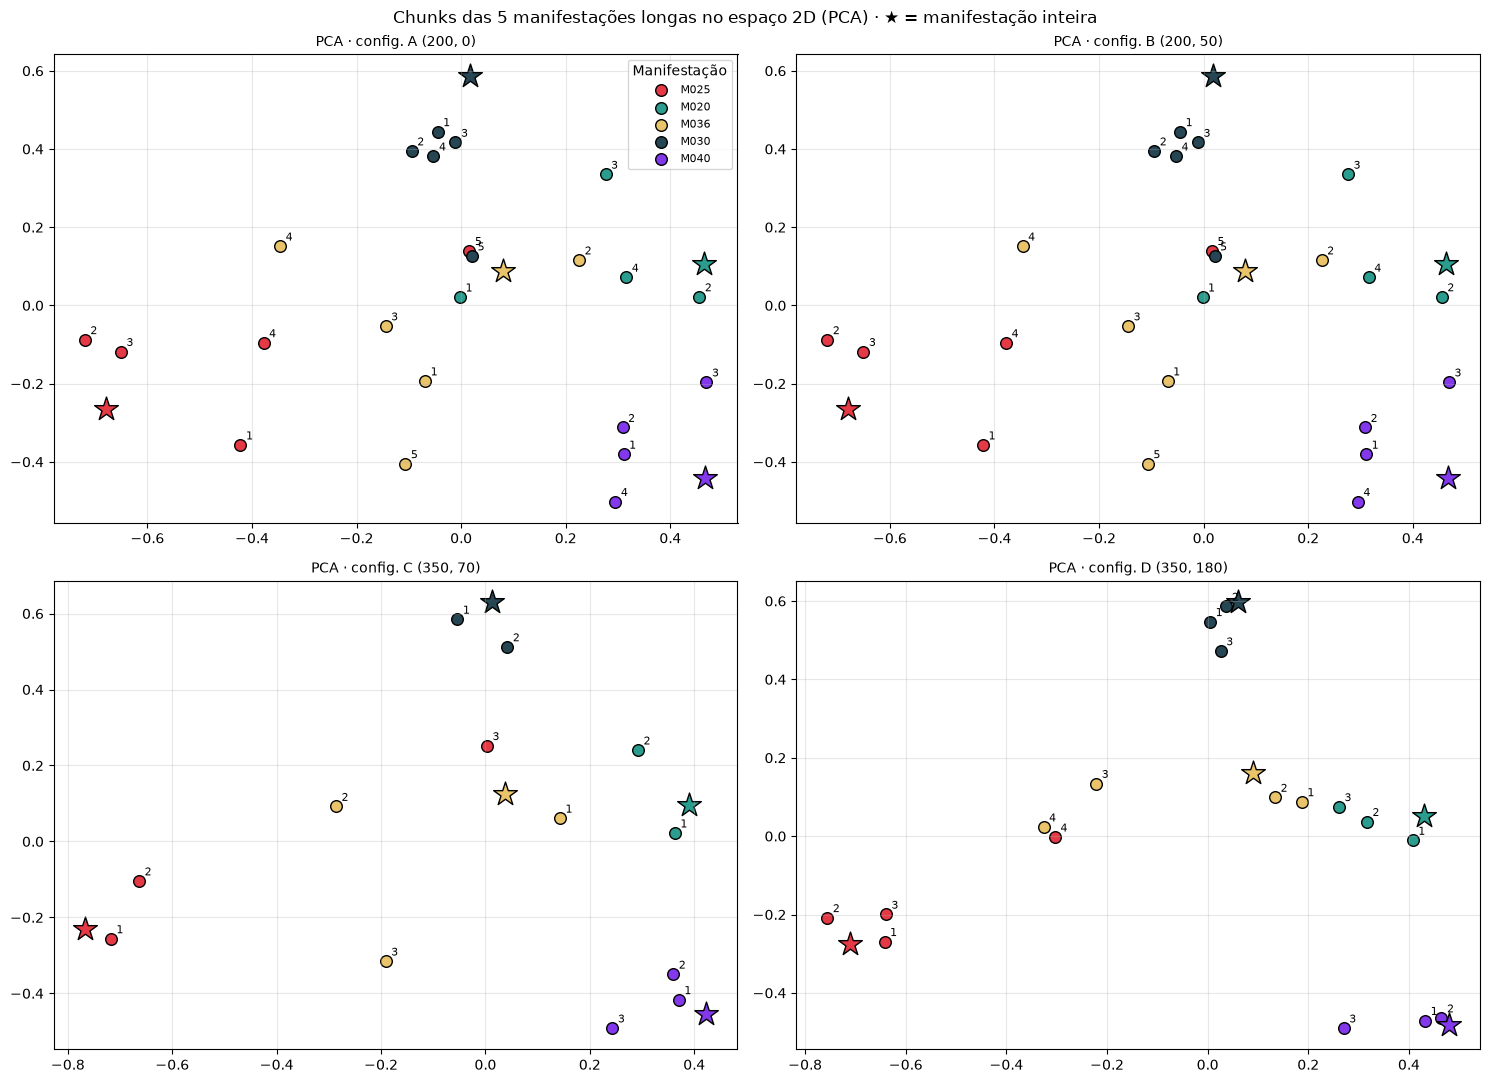

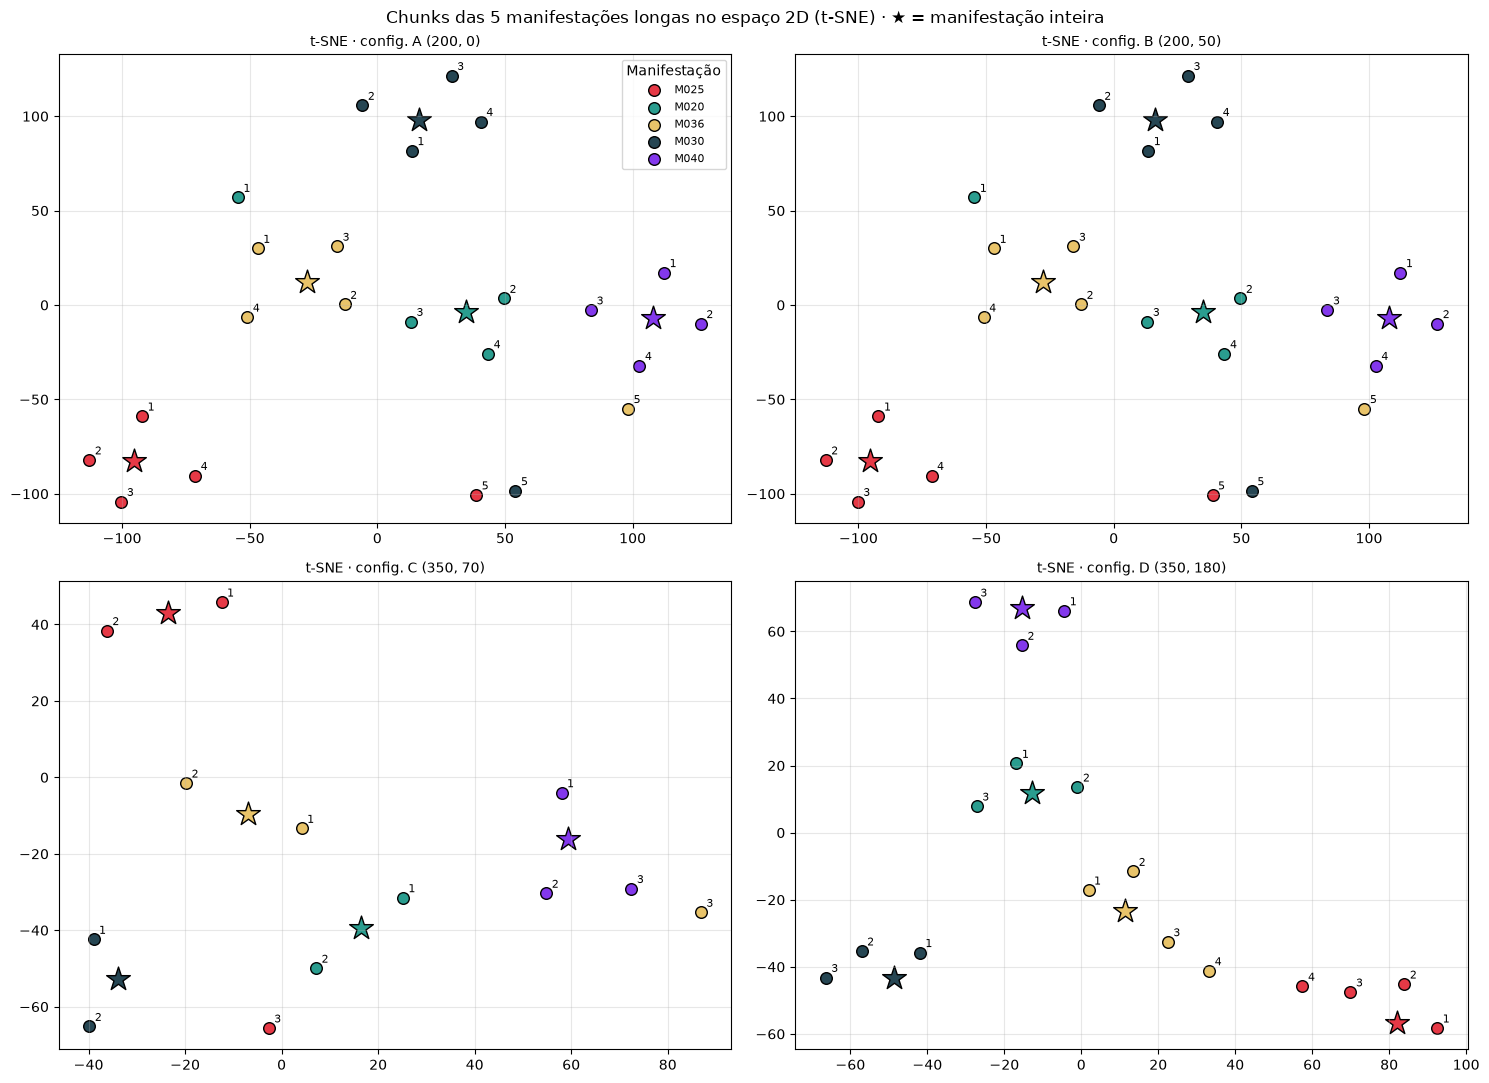

In [15]:
CORES = ["#e63946", "#2a9d8f", "#e9c46a", "#264653", "#8338ec"]
ids_longas = longas["id"].tolist()


def plotar(nome, metodo, ax):
    tabela, vetores = chunks[nome], emb_chunks[nome]
    todos = np.vstack([vetores, np.array([emb_docs[i] for i in ids_longas])])
    if metodo == "PCA":
        coords = PCA(n_components=2, random_state=42).fit_transform(todos)
    else:
        perplexidade = min(5, len(todos) - 1)
        coords = TSNE(n_components=2, perplexity=perplexidade, random_state=42).fit_transform(todos)
    pontos, estrelas = coords[: len(tabela)], coords[len(tabela):]

    for cor, id_ in zip(CORES, ids_longas):
        mascara = (tabela["id"] == id_).to_numpy()
        ax.scatter(pontos[mascara, 0], pontos[mascara, 1], color=cor, s=70, edgecolor="black", label=id_)
        for (x, y), n in zip(pontos[mascara], tabela.loc[mascara, "chunk"]):
            ax.annotate(str(n), (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8)
        k = ids_longas.index(id_)
        ax.scatter(*estrelas[k], color=cor, marker="*", s=320, edgecolor="black")
    ax.set_title(f"{metodo} · config. {nome}", fontsize=10)
    ax.grid(alpha=0.3)


for metodo in ["PCA", "t-SNE"]:
    fig, eixos = plt.subplots(2, 2, figsize=(15, 11))
    for ax, nome in zip(eixos.flat, CONFIGS):
        plotar(nome, metodo, ax)
    eixos[0, 0].legend(title="Manifestação", fontsize=8)
    fig.suptitle(f"Chunks das 5 manifestações longas no espaço 2D ({metodo}) · ★ = manifestação inteira")
    plt.tight_layout()
    plt.show()

## 7. Os chunks da mesma manifestação ficam próximos? (medida numérica)

A projeção em 2D distorce distâncias, então a pergunta também é respondida no espaço original dos embeddings. Comparamos a similaridade média entre chunks da **mesma** manifestação com a similaridade entre chunks de manifestações **diferentes**. Também verificamos, para cada chunk, se o seu vizinho mais próximo pertence à mesma manifestação.

In [16]:
linhas = []
for nome in CONFIGS:
    tabela, vetores = chunks[nome], emb_chunks[nome]
    sim = cosine_similarity(vetores)
    ids_chunks = tabela["id"].to_numpy()
    mesma = ids_chunks[:, None] == ids_chunks[None, :]
    fora_diagonal = ~np.eye(len(tabela), dtype=bool)
    np.fill_diagonal(sim, -1)
    vizinho = sim.argmax(axis=1)
    np.fill_diagonal(sim, 1)
    linhas.append({
        "Configuração": nome,
        "Sim. mesma manifestação": sim[mesma & fora_diagonal].mean(),
        "Sim. manifestações diferentes": sim[~mesma].mean(),
        "Vizinho mais próximo é da mesma manifestação": (ids_chunks[vizinho] == ids_chunks).mean(),
    })

pd.DataFrame(linhas).style.format({
    "Sim. mesma manifestação": "{:.3f}", "Sim. manifestações diferentes": "{:.3f}",
    "Vizinho mais próximo é da mesma manifestação": "{:.0%}",
})

,Configuração,Sim. mesma manifestação,Sim. manifestações diferentes,Vizinho mais próximo é da mesma manifestação
0,"A (200, 0)",0.311,0.183,57%
1,"B (200, 50)",0.311,0.183,57%
2,"C (350, 70)",0.434,0.275,77%
3,"D (350, 180)",0.601,0.285,100%


## 8. Respostas às perguntas do enunciado

| Config. | Chunks | Pares com trecho repetido | Coesão consecutiva | Fidelidade ao documento | Chunks curtos | Vizinho da mesma manifestação |
|---|---|---|---|---|---|---|
| A (200, 0) | 23 | 0 de 18 | 0,350 | 0,624 | 3 | 57% |
| B (200, 50) | 23 | 0 de 18 | 0,350 | 0,624 | 3 | 57% |
| C (350, 70) | 13 | 1 de 8 | 0,502 | 0,743 | 2 | 77% |
| D (350, 180) | 17 | 11 de 12 | 0,714 | 0,803 | 0 | 100% |

**1. Como o overlap influencia a coesão semântica entre chunks consecutivos?**

O overlap aumenta a coesão porque repete o final de um chunk no começo do seguinte, e os dois passam a compartilhar parte do conteúdo. Mas o experimento mostrou um detalhe importante: **no LangChain, o overlap só repete pedaços inteiros**. O `RecursiveCharacterTextSplitter` primeiro corta o texto em frases e depois junta frases até o `chunk_size`. Como as frases destes textos têm de 70 a 175 caracteres, um overlap de 50 não comporta nenhuma frase inteira, e a configuração B saiu **idêntica** à A: mesmos 23 chunks e nenhum trecho repetido. Com o mesmo `chunk_size` de 350, o overlap de 70 (C) repetiu texto em apenas 1 de 8 pares, e o de 180 (D) em 11 de 12. Nesse caso, a coesão consecutiva subiu de 0,502 para 0,714. O custo é a redundância: D gera 17 chunks em vez de 13 (31% a mais para indexar), e o mesmo trecho pode aparecer duas vezes nos resultados de uma busca. Portanto, o overlap só tem efeito quando é maior que as unidades em que o texto foi quebrado.

**2. Qual configuração preserva melhor o sentido das denúncias?**

A configuração **D (350, 180)**. Ela tem a maior fidelidade ao documento (0,803) e nenhum chunk curto, e cada chunk carrega a frase anterior como contexto. O exemplo de M025 mostra a diferença:

- Em **C**, o chunk 2 começa com "Não tinha cardiologista de plantão e o eletrocardiograma estava quebrado…". Lido sozinho, não diz quem estava sendo atendido nem por quê.
- Em **D**, o chunk 2 começa com "Ele chegou com dor no peito às oito da noite…" e só depois fala da falta de cardiologista. A denúncia fica completa: um paciente com dor no peito, sem especialista e sem exame.
- Em **A** e **B**, o último chunk é só "Peço que a prefeitura amplie as equipes e faça a manutenção dos aparelhos." Sozinho, não diz de qual unidade de saúde nem de quais aparelhos.

Nenhuma configuração cortou frases no meio (0% em todas), porque o splitter sempre prefere quebrar no ponto final. A diferença entre elas está em **quanto contexto cada chunk carrega**. Se a redundância for um problema, C é a alternativa mais econômica.

**3. Os chunks de uma mesma manifestação ficam próximos no espaço 2D?**

Depende da configuração. Em **A e B**, os grupos são frouxos: só 57% dos chunks têm como vizinho mais próximo outro chunk da mesma manifestação. No gráfico de PCA, os chunks finais de M025 ("Peço que a prefeitura amplie as equipes…") e de M030 ("Solicitamos reforço no policiamento…") caem praticamente no mesmo ponto: frases curtas de pedido à prefeitura se parecem mais entre si do que com a denúncia de origem. M036, que trata de vários assuntos (transporte, calor, biblioteca), tem os chunks espalhados pelo gráfico. Com chunks maiores, os grupos ficam mais nítidos (77% em C), e em **D** cada manifestação forma um grupo compacto ao redor da sua estrela (100%). Esse último número precisa ser lido com cuidado: em D, chunks vizinhos repetem frases inteiras, o que os aproxima por construção. Mesmo assim, a diferença entre a similaridade dentro da mesma manifestação e entre manifestações diferentes também é a maior em D (0,601 × 0,285), o que confirma que chunks com mais contexto representam melhor a denúncia de origem.